# PerioKPT — Dataset Exploration

This notebook explores and validates the data loading pipeline used for the PerioKPT project, whose goal is to develop a deep learning system for automated analysis of dental radiographs, including tooth localization (bounding boxes) and anatomical keypoint estimation for periodontal bone loss assessment.

Specifically, this notebook verifies that the dataset module (`src/data.py`) works correctly:

1. Locates and exposes the project root, independent of the operating system.
2. Builds PyTorch `DataLoader`s for the cross-validation folds and the final holdout set.
3. Visualizes one sample per split (train / val / test / holdout), overlaying bounding boxes and keypoints, to confirm that the YOLO-format annotations are parsed and aligned correctly.

The goal is to ensure the dataset and preprocessing pipeline are correct and ready to be used for model training.


## Section 1: Environment setup

Locates the project root by walking up from the notebook's folder and adds it to `sys.path`, so that imports from `src` work regardless of where Jupyter is launched from.


In [17]:
import os
import sys
from pathlib import Path


current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent 

if not (project_root / 'data' / 'perio_KPT' / '1_Experiment').exists():
    raise FileNotFoundError(
        f"Folder '1_Experiment' not found in: {project_root}\n"
        f"Content found: {[p.name for p in project_root.iterdir()]}"
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

print(f"project_root: {project_root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project_root: C:\Users\ronca\OneDrive\Desktop\Computer Vision\Computer_Vision_Project


## Section 2. Importing project modules

- `get_dataloaders`: builds the train/val/test/holdout `DataLoader`s from the YOLO annotations.
- `plot_sample_with_annotations`: visualization utility (image + boxes + keypoints).


In [18]:
from src.data import get_dataloaders
from src.utils import plot_sample_with_annotations

print("Imports successful")

Imports successful


## Section 3. Configuration

Main pipeline parameters:

- `box_type`: `'standard_box'` for axis-aligned bounding boxes, `'rotating_box'` for oriented boxes (handling tooth angle).
- `fold`: cross-validation fold index (0–4). The same `config` is also used to build the `holdout` split, which is independent of the folds.


In [19]:
config = {
    "data_dir": str(project_root / "data" / "perio_KPT" / "1_Experiment"),
    "box_type": "standard_box",   # or "rotating_box"
    "batch_size": 1,
    "fold": 0                     # 0–4
}

print("Configuration")
print(f"  • Box type  : {config['box_type']}")
print(f"  • Fold      : {config['fold']}")
print(f"  • Batch size: {config['batch_size']}")

Configuration
  • Box type  : standard_box
  • Fold      : 0
  • Batch size: 1


## Section 4. Loading the DataLoaders

A single call to `get_dataloaders` produces all the required splits (`train`, `val`, `test`, `holdout`).


In [20]:
dls = get_dataloaders(**config)

print(f"✅ Train batches   : {len(dls['train'])}")
print(f"✅ Test batches    : {len(dls['test'])}")
print(f"✅ Holdout batches : {len(dls['holdout'])}")

[*] Inizializzazione DataLoader - Type: standard_box, Fold: 0, Batch Size: 1
✅ Train batches   : 548
✅ Test batches    : 148
✅ Holdout batches : 75


## Section 5. Visual check per split

For each split (train, val, test, holdout) a single batch is pulled and visualized with `plot_sample_with_annotations`, to check that boxes, keypoints, and angles are correctly aligned with the image.


Shape immagine : torch.Size([1, 1, 128, 128])
Boxes[0] shape : torch.Size([4])


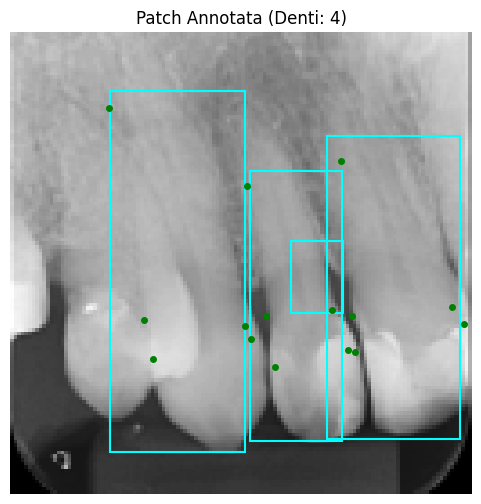

In [21]:
batch_imgs, batch_labels = next(iter(dls['train']))

print(f"Shape immagine : {batch_imgs.shape}")
print(f"Boxes[0] shape : {batch_labels['boxes'][0][0].shape}")  # deve essere torch.Size([4])

plot_sample_with_annotations(batch_imgs[0], {
    'classes'  : batch_labels['classes'][0],
    'boxes'    : batch_labels['boxes'][0],
    'keypoints': batch_labels['keypoints'][0],
    'angles'   : batch_labels['angles'][0]
})

## Section 6. Multi-sample grid (train)

Side-by-side visualization of several consecutive training samples, useful for a quick qualitative check across more images at once.


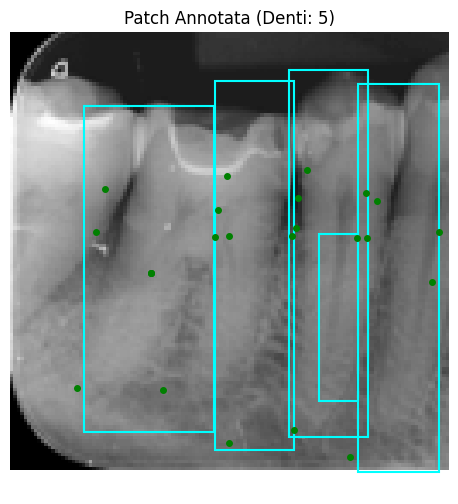

In [22]:
batch_imgs_test, batch_labels_test = next(iter(dls['test']))

plot_sample_with_annotations(batch_imgs_test[0], {
    'classes'  : batch_labels_test.get('classes',   [[]])[0],
    'boxes'    : batch_labels_test.get('boxes',     [[]])[0],
    'keypoints': batch_labels_test.get('keypoints', [[]])[0],
    'angles'   : batch_labels_test.get('angles',    [[]])[0]
})

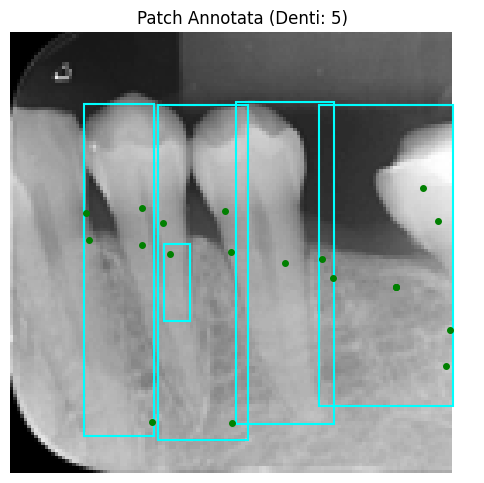

In [23]:
batch_imgs_h, batch_labels_h = next(iter(dls['holdout']))

plot_sample_with_annotations(batch_imgs_h[0], {
    'classes'  : batch_labels_h.get('classes',   [[]])[0],
    'boxes'    : batch_labels_h.get('boxes',     [[]])[0],
    'keypoints': batch_labels_h.get('keypoints', [[]])[0],
    'angles'   : batch_labels_h.get('angles',    [[]])[0]
})

## Section 7. Final sanity check

Consistency check on the shape of the boxes returned by the DataLoader: each box must have shape `[4]` (standard coordinates) — a minimal check before feeding the data into a model.


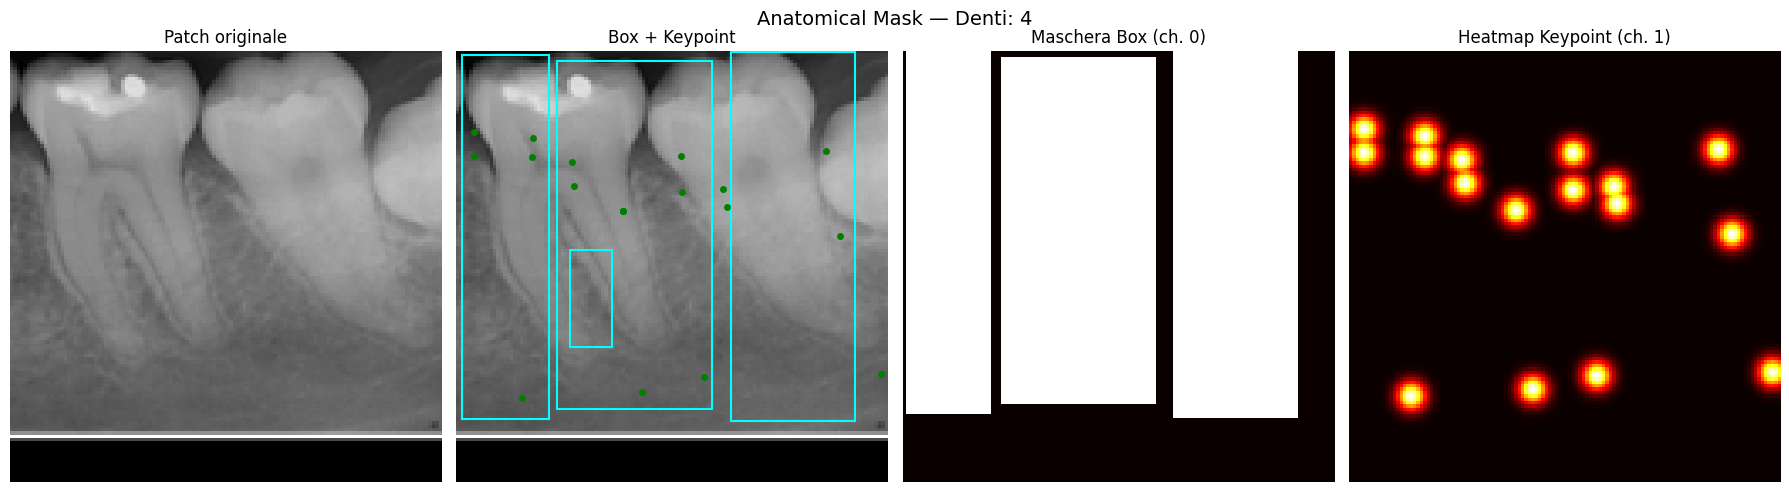

Maschera shape : torch.Size([2, 128, 128])
Box mask range : [0.00, 1.00]
KPT mask range : [0.00, 1.00]


In [24]:
from src.utils import plot_sample_with_mask

batch_imgs, batch_labels = next(iter(dls['train']))

mask = plot_sample_with_mask(batch_imgs[0], {
    'classes'  : batch_labels['classes'][0],
    'boxes'    : batch_labels['boxes'][0],
    'keypoints': batch_labels['keypoints'][0],
    'angles'   : batch_labels['angles'][0]
})

print(f"Maschera shape : {mask.shape}")   # torch.Size([2, 128, 128])
print(f"Box mask range : [{mask[0].min():.2f}, {mask[0].max():.2f}]")
print(f"KPT mask range : [{mask[1].min():.2f}, {mask[1].max():.2f}]")

## Conclusions

- The `DataLoader`s for `train`, `val`, `test`, and `holdout` are correctly built from the YOLO-format annotations.
- Annotations (bounding boxes, keypoints, angles) are correctly aligned with the images across all verified splits.
- The dataset and preprocessing pipeline are validated and ready to be used as the basis for further model development (e.g. patch extraction and training).
